In [12]:
import os
import pickle as pkl
import sys

import matplotlib.pyplot as plt
from matplotlib import rcParams
import numpy as np
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join("..", "src")))
import utils

In [13]:
FIG_WIDTH = 7.5  # width of figure in inches

TINY_SIZE = 6
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=TINY_SIZE, titleweight='bold')  # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=TINY_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=TINY_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

In [14]:
try:
    x0 = np.load("../scripts/variables/x0_00.npy")
    inputs = np.load("../scripts/variables/inputs_00.npy")
    print("Loaded variables from previous runs")
except Exception:
    print("Run 00_Parameter_Distributions.py script")

Loaded variables from previous runs


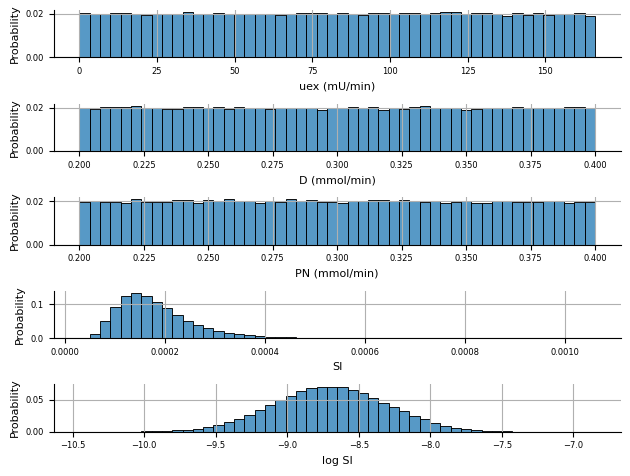

In [15]:
states = ["BG (mmol/L)", "I (mU/L)", "Q (mu/L)", "P1 (mmol)", "P2 (mmol)", "P (mmol)", "uen (mU/min)"]
input_labels = ["uex (mU/min)", "D (mmol/min)", "PN (mmol/min)", "SI"]

fig, ax = plt.subplots(inputs.shape[0]+1, 1)
for i in range(inputs.shape[0]):
    sns.histplot(data=inputs[i, :], bins=50, stat="probability", ax=ax[i])
    ax[i].set_xlabel(input_labels[i])
    ax[i].grid()
sns.histplot(data=np.log(inputs[-1,:]), bins=50, stat="probability", ax=ax[-1])
ax[-1].set_xlabel("log SI")
ax[-1].grid()
fig.tight_layout()
# fig.savefig("3_1.svg", format="svg")

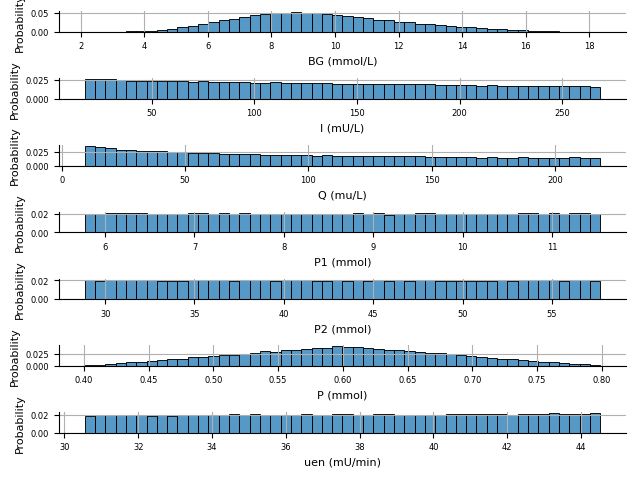

In [16]:
fig, ax = plt.subplots(x0.shape[0], 1)
for i in range(x0.shape[0]):
    sns.histplot(data=x0[i, :], bins=50, stat="probability", ax=ax[i])
    ax[i].set_xlabel(states[i])
    ax[i].grid()
fig.tight_layout()
# fig.savefig("3_2.svg", format="svg")

In [17]:
x0.shape

(7, 100000)

In [18]:
print("Mean initial states: ", np.mean(x0, axis=1))
print("Initial Covariance: \n", np.diag(np.cov(x0, rowvar=True, bias=False)))

Mean initial states:  [  9.58079735 133.14190461  98.21108525   8.65237235  43.26186174
   0.59968444  37.64565979]
Initial Covariance: 
 [6.45274144e+00 5.22007344e+03 3.71393129e+03 2.78551607e+00
 6.96379017e+01 6.65598525e-03 1.63245461e+01]


In [19]:
try:
    patient_data = pkl.load(open("../scripts/variables/patient_data_00.pkl", "rb"))
    print("Loaded variable from previous run")
except Exception:
    print("Run 00_Patient_Cohort.py script")

Loaded variable from previous run


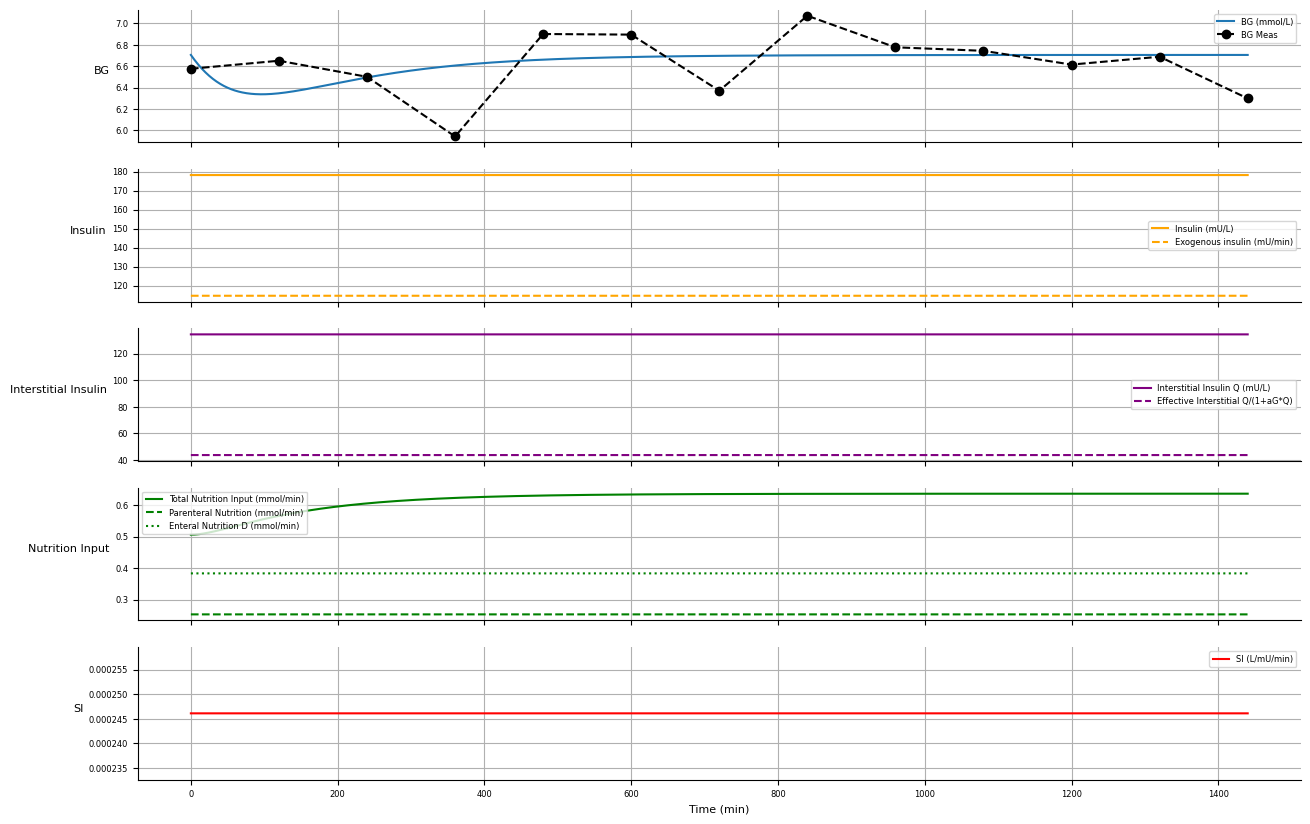

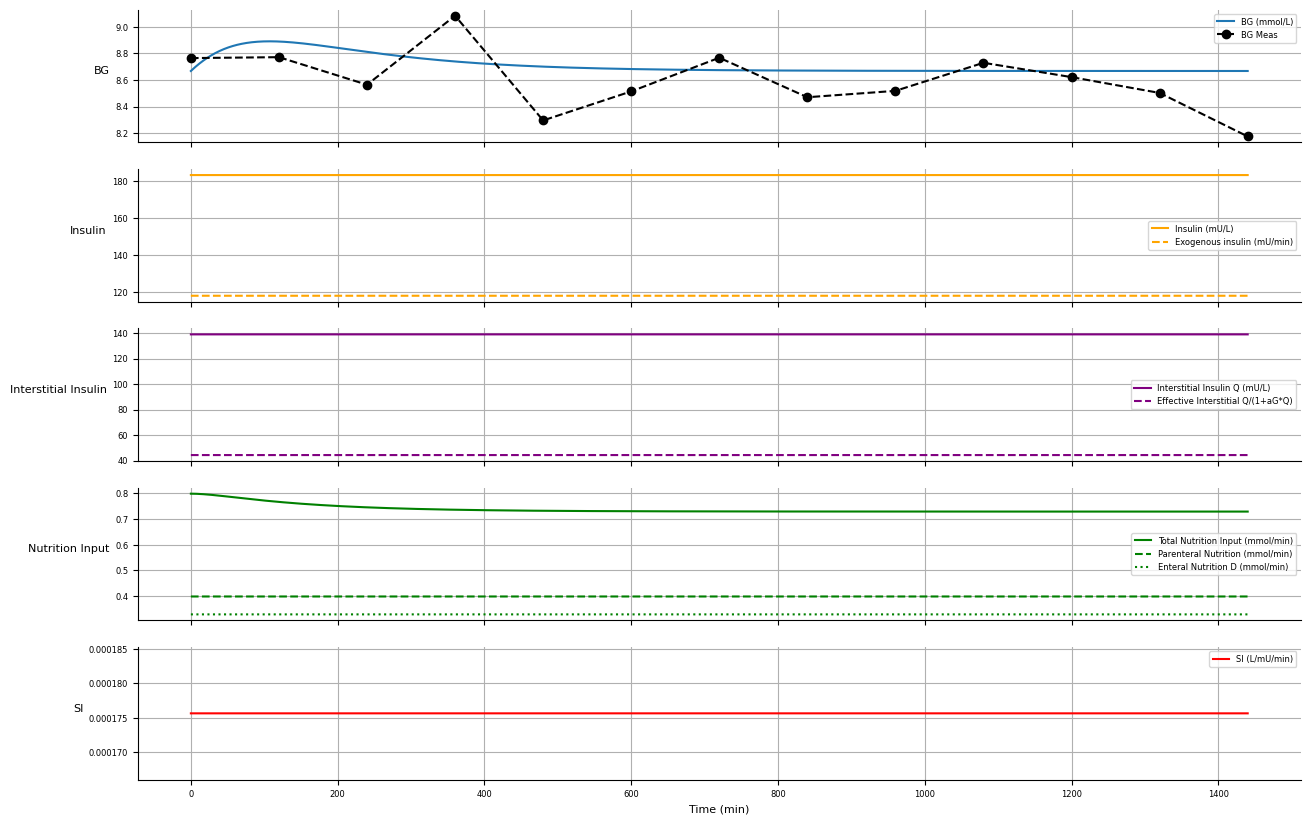

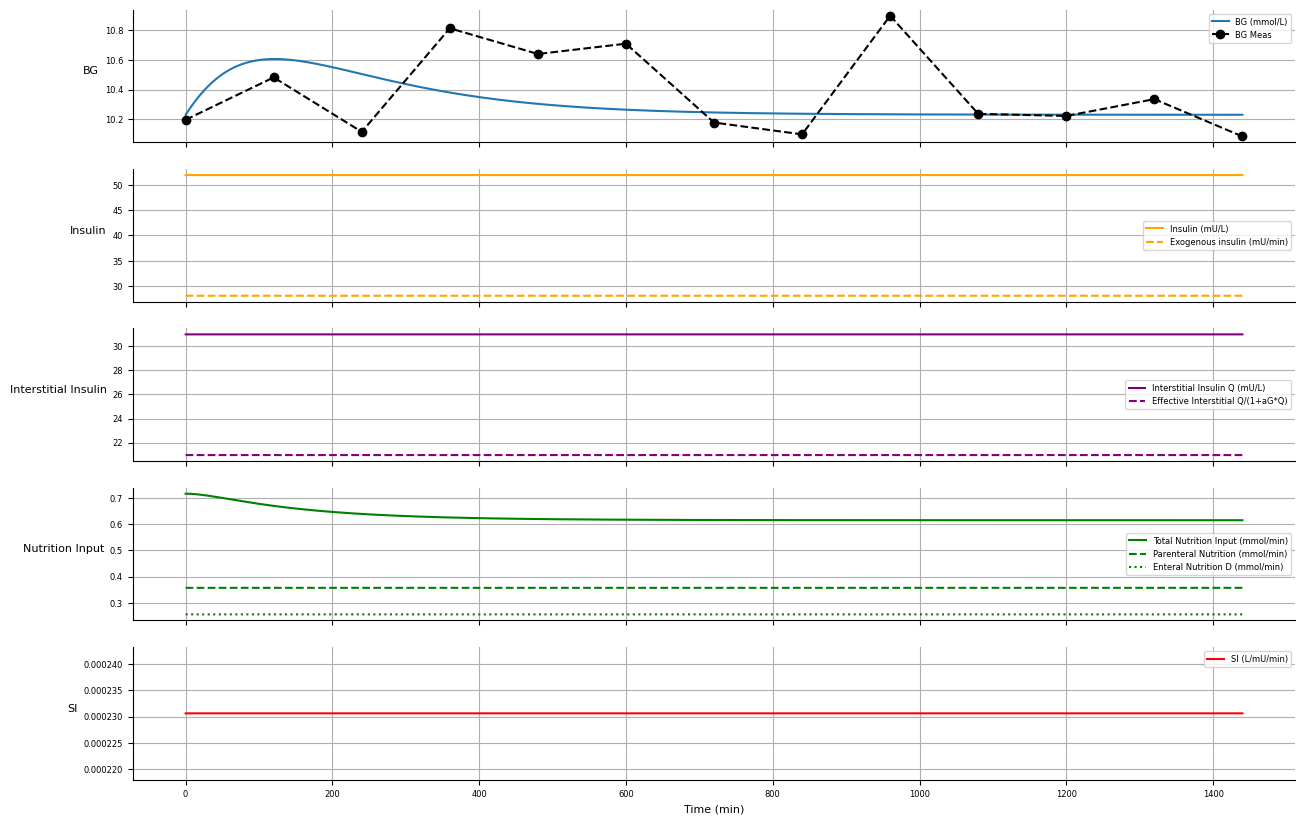

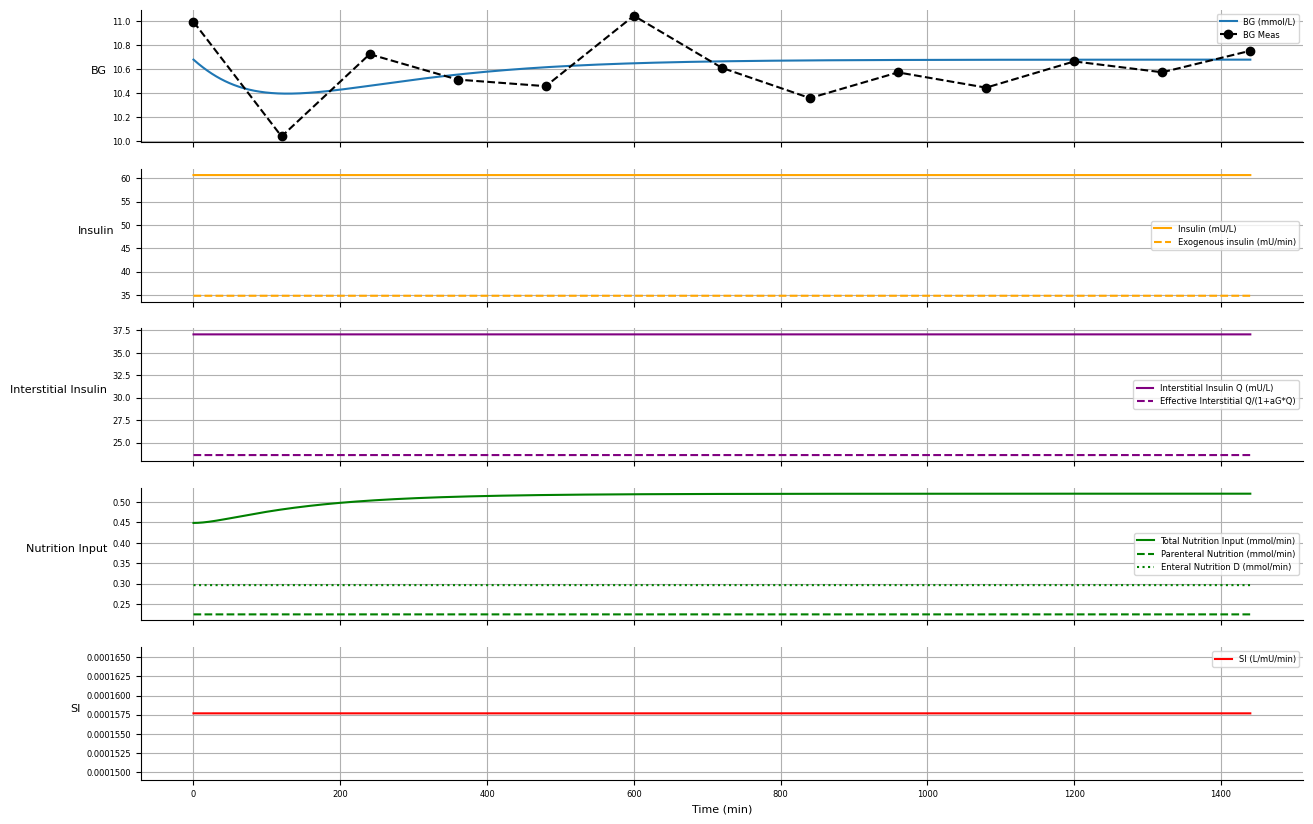

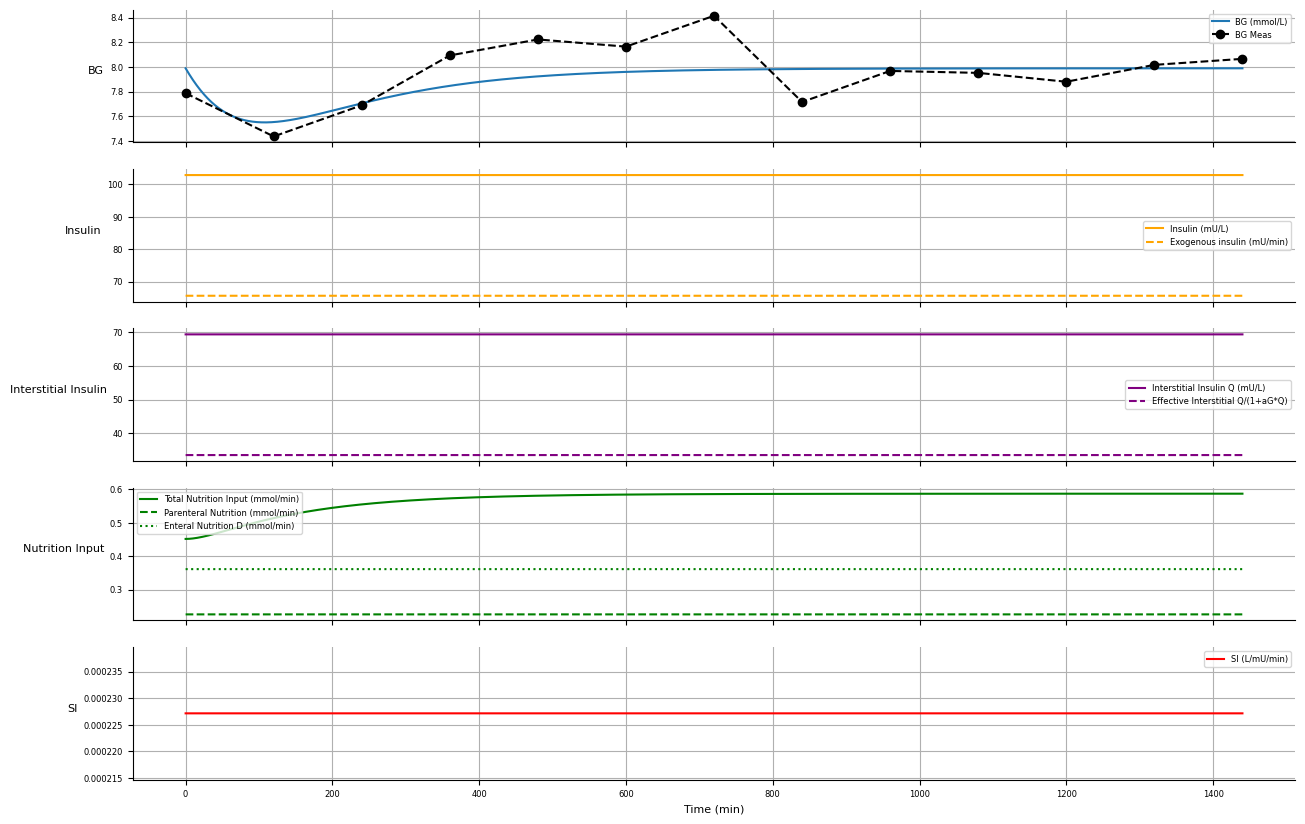

In [20]:
num_patients = len(patient_data)

for i in range(num_patients):
    G = patient_data[i]["BG"]
    G_meas = patient_data[i]["BG_meas"]
    Q = patient_data[i]["Q"]
    I = patient_data[i]["I"]  # noqa: E741
    P1 = patient_data[i]["P1"]
    P2 = patient_data[i]["P2"]
    P = patient_data[i]["P"]
    t = patient_data[i]["t"]
    t_meas = patient_data[i]["t_meas"]
    uex = patient_data[i]["uex"]
    D = patient_data[i]["D"]
    PN = patient_data[i]["PN"]
    SI = patient_data[i]["SI"]
    utils.plot_model(t, t_meas, G, G_meas, Q, I, P1, P2, P, uex, PN, D, SI)
